# EDA (EXPLORATORY DATA ANALYSIS)

1. load datasets

2. clean data(missing values,duplicates,types)

3. treat outliers

4. univariate,bivariate and multivariate analysis

5. insights 

outlier - a datapoint that is significantly different from other observations in a dataset.

how outliers will come---?
1.Measurement error
2.data entry mistakes


why they are important---?
1.They can be errors
2.They effect the data analysis

How to identify the outliers---?

1.Statistical methods

--->Interquartile Range(IQR)

--->Z-Score

2.Visualization Tech

--->Box Plots

--->Scatter plots

--->Histograms


### Univariate analysis - method that analyzes a single variable to describe its characteristics,finding patterns and summarize the data.
#### It involves only one variable
### Bivariate analysis - It will give the relationship b/n 2 variables. It helps to find if there is any co-relation, association or connection b/n the 2 variables.
#### It involves 2 variables (x & y)
### Multivariate analysis - To understand how multiple factors interact and influence each other.
#### It involves more than 2 variables

Example -
How our age,income and education level together influence the purchasing behavior.

# ETL

# ELT

## EDA : < Dataset >

1. Load & Overview

2. Cleaning (missing, dupes, dtypes)

3. Uni,Bi and Multi analysis
 
4. Outlier - IQR, z-score

5. Feature engineering

6. Key Insights


### Feature Engineering - " Feature Engineering is the process of turning raw into useful features " that helps to improve the performance of machine learning models.


In [18]:
import sys
print(sys.executable)

d:\Fullstackdatascientist\venv\python.exe


In [19]:
!{sys.executable} -m pip install pandas

In [20]:
!{sys.executable} -m pip install numpy

In [21]:
!{sys.executable} -m pip install matplotlib

In [22]:
!{sys.executable} -m pip install seaborn

In [23]:
# 1. Load libraries & Datasets

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [24]:
# Basic info & overview
print("shape of the dataset:",df.shape)

print("\n Data info: \n")
df.info()

shape of the dataset: (891, 15)

 Data info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [25]:
# summary and statistics
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Missing values analysis

missing = pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/len(df))*100
})
missing.sort_values(by='missing_percent',ascending=False)

,missing_count,missing_percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


In [27]:
# 4.Handling Missing values

# fill the numeric missing values with mean

df['age']=df['age'].fillna(df['age'].mean())

# fill categorical missing values with mode

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop 'deck'  because it has too many missing values
df.drop(columns=['deck'],inplace=True)

# Missing values analysis

missing = pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/len(df))*100
})
missing.sort_values(by='missing_percent',ascending=False)


# duplicate and data type check

print("Duplicate rows: ",df.duplicated().sum())

# convert some columns to categorical type

df['class']=df['class'].astype('category')
df['sex']=df['sex'].astype('category')
df.info()

Duplicate rows:  111
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(4)
memory usage: 73.5+ KB


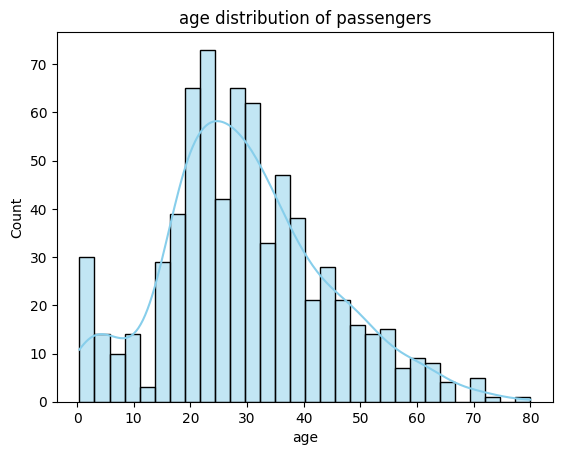

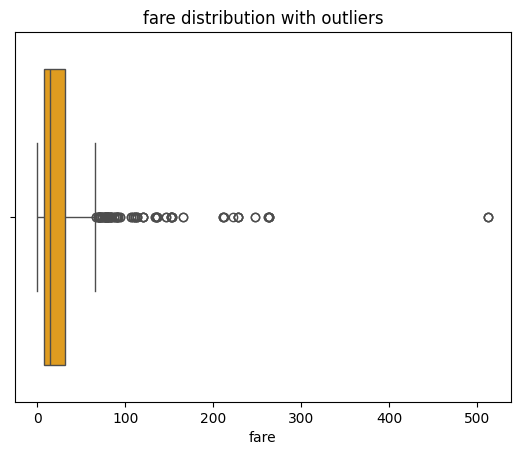

In [17]:
# 6. Univariate analysis-numerical features
num_cols=df.select_dtypes(include=['float64','int64']).columns
df[num_cols].describe()

# Histogram : Age
sns.histplot(df['age'],bins=30,kde=True,color='skyblue')
plt.title("age distribution of passengers")
plt.show()

#Boxplot :Large
sns.boxplot(x=df['fare'],color='orange')
plt.title("fare distribution with outliers")
plt.show()

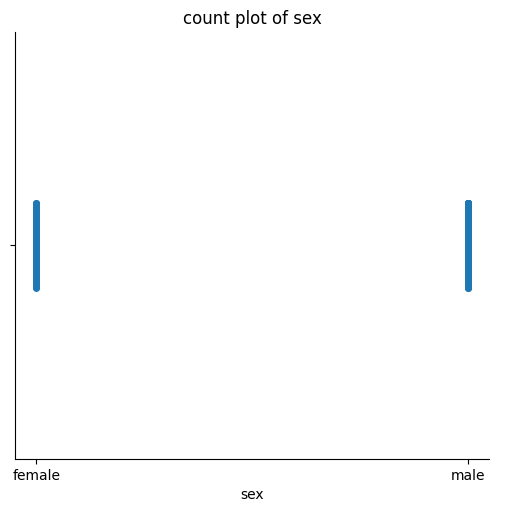

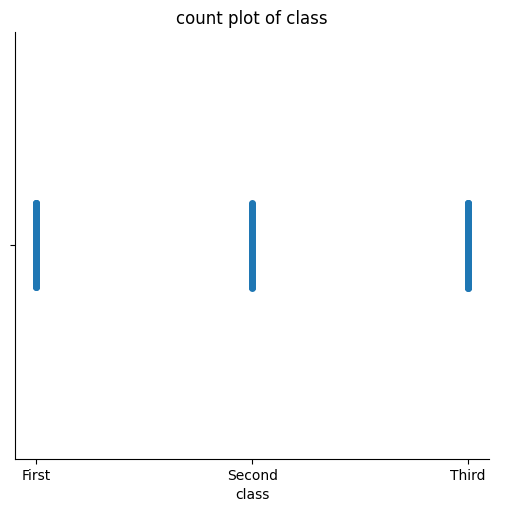

In [28]:
cat_clos = df.select_dtypes('category').columns

for col in cat_clos:
    sns.catplot(x=col,data=df)
    plt.title(f"count plot of {col}")
    plt.show()

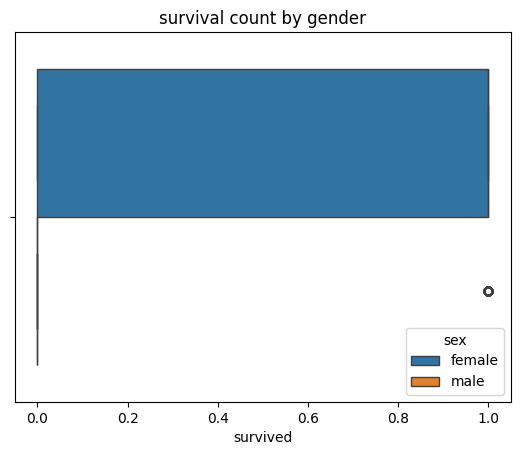

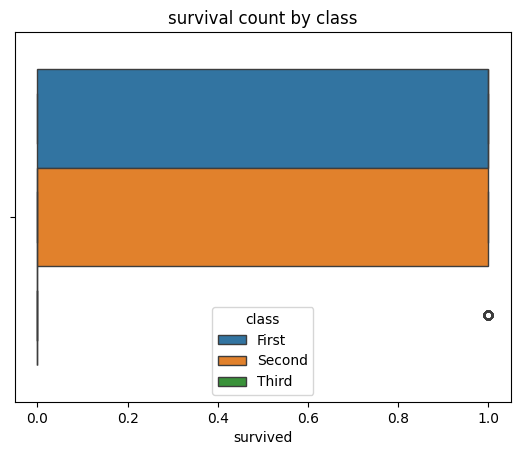

In [29]:
# Bivariate analysis  -Numerical vs Categorical 

sns.boxplot(x='survived',hue='sex',data=df)
plt.title('survival count by gender')
plt.show()

sns.boxplot(x='survived',hue='class',data=df)
plt.title('survival count by class')
plt.show()


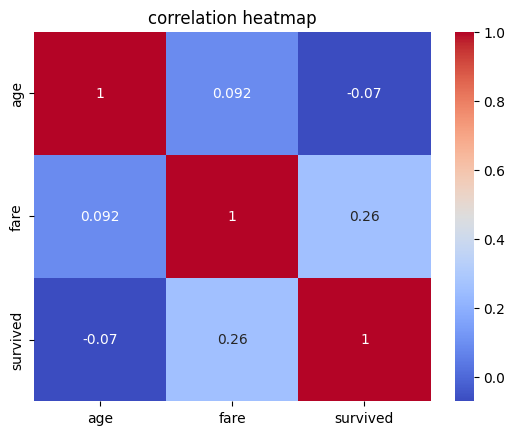

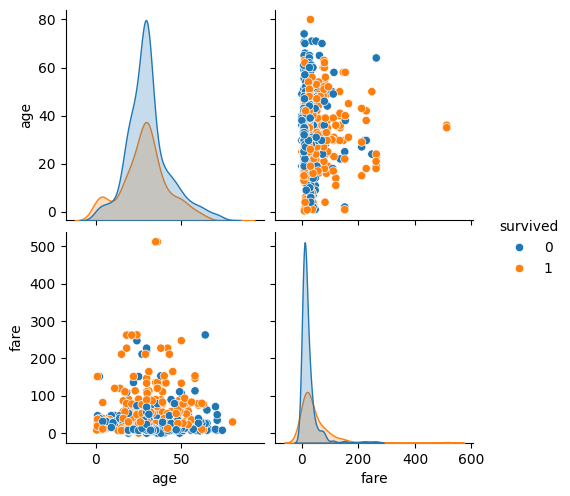

In [32]:
# corelation and multivariate analysis

corr=df[['age','fare','survived']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

sns.pairplot(df[['age','fare','survived']],hue='survived')
plt.show()

Insights:

1.Fare has a positive correlation with survival

2.Age shows a slight negative correlation with survival

Number of outliers in fare: 20


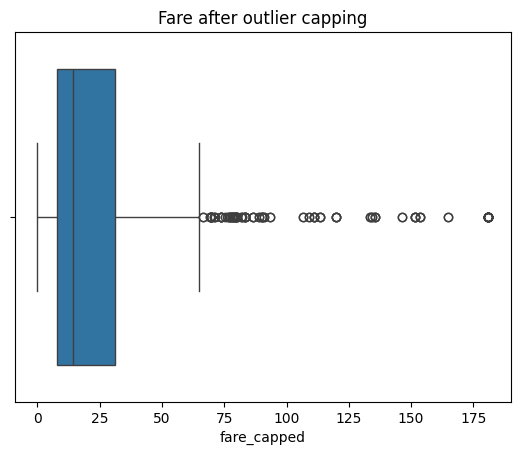

In [33]:
# outlier detection using IQR

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

lower=Q1-1.5*100
upper=Q3+1.5*100

outliers=df[(df['fare']<lower)|(df['fare']>upper)]
print("Number of outliers in fare:",len(outliers))



#outliers
df['fare_capped']=df['fare'].clip(lower,upper)
sns.boxplot(x=df['fare_capped'])
plt.title("Fare after outlier capping")
plt.show()

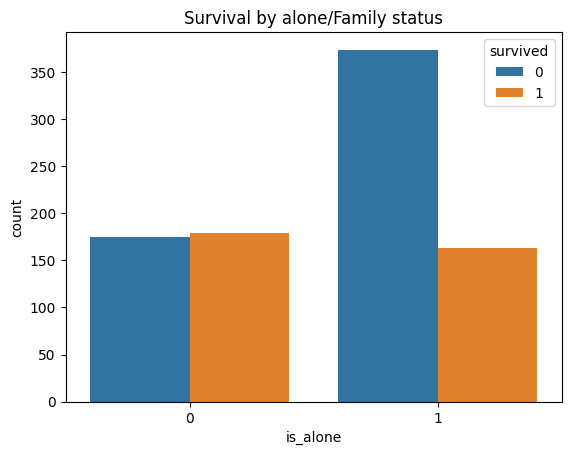


 Cleaned Titanic data saved as titanic_cleaned.csv
d:\Fullstackdatascientist\WEEK-6


In [34]:
# Feature Engineering 

# Create new Features

df['family_size']=df['sibsp']+df['parch']+1
df['is_alone']=(df['family_size']==1).astype(int)

sns.countplot(x='is_alone',hue='survived',data=df)
plt.title('Survival by alone/Family status')
plt.show()
df.to_csv("Titanic_cleaned.csv",index=False)
print("\n Cleaned Titanic data saved as titanic_cleaned.csv")
import os
print(os.getcwd())